In [28]:
%load_ext autoreload
%autoreload 2

import featuregraph as fg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
eastman = fg.datasets.eastman(
    dataset="faultfree_training",
    fault_number=0,
    simulation_run=1,
)

group = ["fault_number", "simulation_run"]

faulty_eastman_oscillation = fg.oscillation.Oscillation(
    signals="reactor_pressure",
    group=group,
    smooth_signal=True,
    smooth_window=20,
)
faulty_eastman_oscillation_features = faulty_eastman_oscillation.fit_transform(eastman)
faulty_eastman_oscillation_objects = faulty_eastman_oscillation.summarize(
    faulty_eastman_oscillation_features,
    signal="reactor_pressure",
)

faulty_eastman_accumulation = fg.accumulation.Accumulation(
    signals="reactor_pressure",
    group=group,
)
faulty_eastman_accumulation_features = faulty_eastman_accumulation.fit_transform(
    faulty_eastman_oscillation_features
)
faulty_eastman_accumulation_objects = faulty_eastman_accumulation.summarize(
    faulty_eastman_accumulation_features,
    signal="reactor_pressure",
)

In [30]:
faulty_eastman = fg.datasets.eastman(
    dataset="faulty_training",
    fault_number=1,
    simulation_run=1,
)

group = ["fault_number", "simulation_run"]

faulty_eastman_oscillation = fg.oscillation.Oscillation(
    signals="reactor_pressure",
    group=group,
    smooth_signal=True,
    smooth_window=20,
)
faulty_eastman_oscillation_features = faulty_eastman_oscillation.fit_transform(eastman)
faulty_eastman_oscillation_objects = faulty_eastman_oscillation.summarize(
    faulty_eastman_oscillation_features,
    signal="reactor_pressure",
)

faulty_eastman_accumulation = fg.accumulation.Accumulation(
    signals="reactor_pressure",
    group=group,
)
faulty_eastman_accumulation_features = faulty_eastman_accumulation.fit_transform(
    faulty_eastman_oscillation_features
)
faulty_eastman_accumulation_objects = faulty_eastman_accumulation.summarize(
    faulty_eastman_accumulation_features,
    signal="reactor_pressure",
)

In [31]:
faulty_eastman_oscillation_objects

BehaviorObjects(behavior_type='oscillation', signal='reactor_pressure', table=    fault_number  simulation_run  oscillation_id  is_complete  start_index  \
0              0               1               1         True         28.0   
1              0               1               2         True         65.0   
2              0               1               3         True         82.0   
3              0               1               4         True        113.0   
4              0               1               5         True        121.0   
..           ...             ...             ...          ...          ...   
59             0               1              60         True       2820.0   
60             0               1              61         True       2851.0   
61             0               1              62         True       2902.0   
62             0               1              63         True       2912.0   
63             0               1              64         True   

In [34]:
fault_start = 600
fault_end = 1200

faulty_eastman_oscillation_objects.table["fault_response"] = (
    (faulty_eastman_oscillation_objects.table["end_index"] >= fault_start)
    & (faulty_eastman_oscillation_objects.table["start_index"] <= fault_end)
)

(<Figure size 1600x300 with 1 Axes>,
 array([<Axes: xlabel='Time', ylabel='reactor_pressure'>], dtype=object))

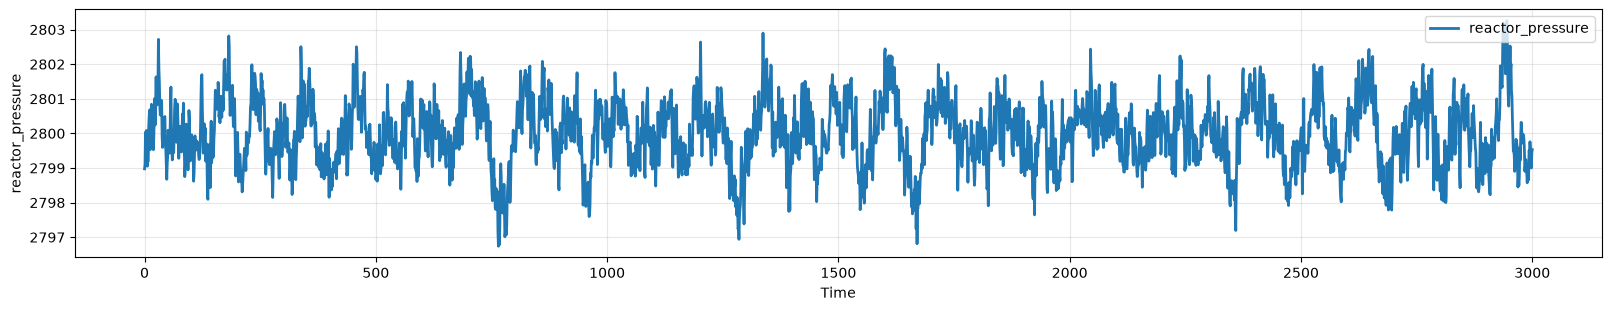

In [ ]:
fg.plot(eastman, [['reactor_pressure']])

(<Figure size 1600x300 with 1 Axes>,
 array([<Axes: xlabel='Time', ylabel='reactor_pressure'>], dtype=object))

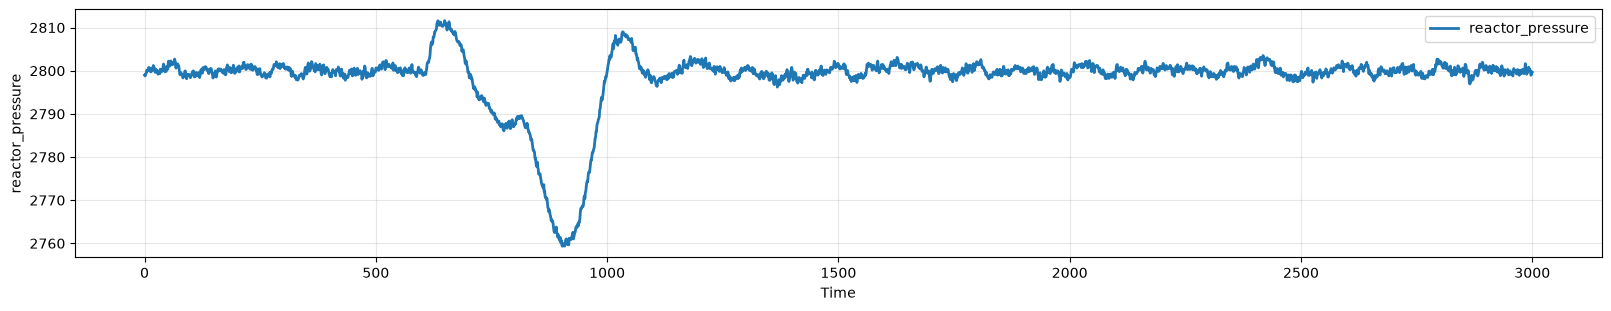

In [ ]:
fg.plot(faulty_eastman, [['reactor_pressure']])